In [4]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import tensorflow
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from keras import callbacks
from tensorflow.keras import layers, Sequential, callbacks
from tensorflow.keras.layers import Conv2D, Flatten, Dense, LSTM, Dropout, GRU, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers.schedules import ExponentialDecay

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [5]:
data=pd.read_csv("traffic.csv")
data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [6]:
data['DateTime']=pd.to_datetime(data['DateTime'])

data["Year"]=data['DateTime'].dt.year

data["Month"]=data['DateTime'].dt.month

data["Date_no"]=data['DateTime'].dt.day

data["Hour"]=data['DateTime'].dt.hour

data["Day"]= data['DateTime'].dt.strftime("%A")
data

,DateTime,Junction,Vehicles,ID,Year,Month,Date_no,Hour,Day
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,Sunday
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,Sunday
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,Sunday
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,Sunday
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,Sunday
...,...,...,...,...,...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194,2017,6,30,19,Friday
48116,2017-06-30 20:00:00,4,30,20170630204,2017,6,30,20,Friday
48117,2017-06-30 21:00:00,4,16,20170630214,2017,6,30,21,Friday
48118,2017-06-30 22:00:00,4,22,20170630224,2017,6,30,22,Friday


<Axes: xlabel='Date_no', ylabel='Vehicles'>

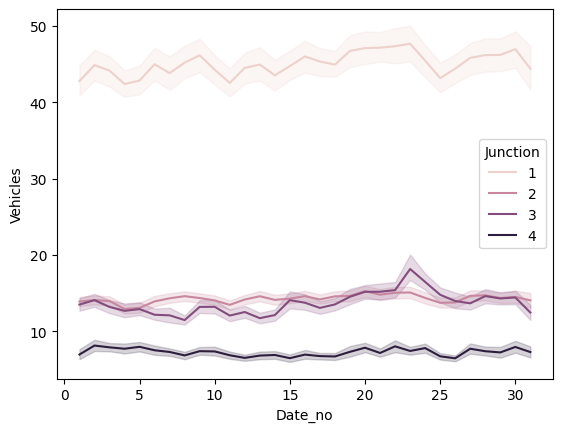

In [7]:
sns.lineplot(x=data['Date_no'],y="Vehicles",data=data,hue='Junction')

In [8]:
data = data[(data['Junction'] == 1)]
def Normalize(df,col):
    average = df[col].mean()
    stdev = df[col].std()
    df_normalized = (df[col] - average) / stdev
    df_normalized = df_normalized.to_frame()
    return df_normalized, average, stdev

def Difference(df,col, interval):
    diff = []
    for i in range(interval, len(df)):
        value = df[col][i] - df[col][i - interval]
        diff.append(value)
    return diff

In [9]:
df_N, av, std = Normalize(data, "Vehicles")
Diff = Difference(df_N, col="Vehicles", interval=(24*7)) #taking a week's diffrence
df_N = df_N[24*7:]
df_N.columns = ["Norm"]
df_N["Diff"]= Diff
df = df_N["Diff"].dropna()
df = df.to_frame()
df.head()

,Diff
168,-0.086925
169,0.130387
170,0.043462
171,0.043462
172,0.043462


In [10]:
df.shape

(14424, 1)

In [11]:
def Split_data(df):
    training_size = int(len(df)*0.80)
    data_len = len(df)
    train, test = df[0:training_size],df[training_size:data_len] 
    train, test = train.values.reshape(-1, 1), test.values.reshape(-1, 1)
    return train, test

df_train, df_test = Split_data(df)

In [12]:
def TnF(df):
    end_len = len(df)
    X = []
    y = []
    steps = 32
    for i in range(steps, end_len):
        X.append(df[i - steps:i, 0])
        y.append(df[i, 0])
    X, y = np.array(X), np.array(y)
    return X ,y

def FeatureFixShape(train, test):
    train = np.reshape(train, (train.shape[0], train.shape[1], 1))
    test = np.reshape(test, (test.shape[0],test.shape[1],1))
    return train, test

X_train, y_train = TnF(df_train)
X_test, y_test = TnF(df_test)
X_train, X_test = FeatureFixShape(X_train, X_test)

In [13]:
X_train, X_test = FeatureFixShape(X_train, X_test)
from sklearn.metrics import mean_absolute_error

lr_schedule = ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=10000,
    decay_rate=0.9)

def MLP_model(X_Train, y_Train, X_Test, y_Test):
    X_Train = np.squeeze(X_Train)  # This line removes the unnecessary dimension
    X_Test = np.squeeze(X_Test)    # Do the same for the test data
    early_stopping = callbacks.EarlyStopping(min_delta=0.001,patience=10, restore_best_weights=True) 
    model = Sequential()
    model.add(Dense(100, activation='relu', input_dim=X_Train.shape[1]))
    model.add(Dropout(0.2))
    model.add(Dense(20, activation='relu', input_dim=X_Train.shape[1]))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9),loss='mean_squared_error')
    model.fit(X_Train, y_Train, validation_data=(X_test, y_test), epochs=50, batch_size=120, callbacks=[early_stopping])
    pred_MLP = model.predict(X_Test)
    return pred_MLP

In [14]:
def RMSE_Value(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))
    return rmse

def MAE_Value(test,predicted):
    mae = mean_absolute_error(test, predicted)
    print("The MAE is {}.".format(mae))
    return mae

#To plot the comparitive plot of targets and predictions
def PredictionsPlot(test,predicted,m):
    plt.figure(figsize=(12,5))
    plt.plot(test, color=colors[m],label="True Value",alpha=0.5 )
    plt.plot(predicted,label="Predicted Values")
    plt.title("Traffic Prediction Vs True values")
    plt.xlabel("DateTime")
    plt.ylabel("Number of Vehicles")
    plt.legend()
    plt.show()

In [15]:
Pred_MLP = MLP_model(X_train,y_train,X_test, y_test)


Epoch 1/50

96/96 [==============================] - 1s 4ms/step - loss: 0.0797 - val_loss: 0.0745
Epoch 2/50
96/96 [==============================] - 0s 2ms/step - loss: 0.0599 - val_loss: 0.0660
Epoch 3/50
96/96 [==============================] - 0s 2ms/step - loss: 0.0539 - val_loss: 0.0624
Epoch 4/50
96/96 [==============================] - 0s 3ms/step - loss: 0.0531 - val_loss: 0.0603
Epoch 5/50
96/96 [==============================] - 0s 3ms/step - loss: 0.0515 - val_loss: 0.0594
Epoch 6/50
96/96 [==============================] - 0s 4ms/step - loss: 0.0500 - val_loss: 0.0585
Epoch 7/50
96/96 [==============================] - 0s 3ms/step - loss: 0.0495 - val_loss: 0.0585
Epoch 8/50
96/96 [==============================] - 0s 3ms/step - loss: 0.0502 - val_loss: 0.0588
Epoch 9/50
96/96 [==============================] - 0s 3ms/step - loss: 0.0486 - val_loss: 0.0579
Epoch 10/50
96/96 [==============================] - 0s 3ms/step - loss: 0.0486 - val_loss: 0.0578
Epoch 11/50
96/96

The root mean squared error is 0.23834953860500654.
The MAE is 0.17188067329235995.


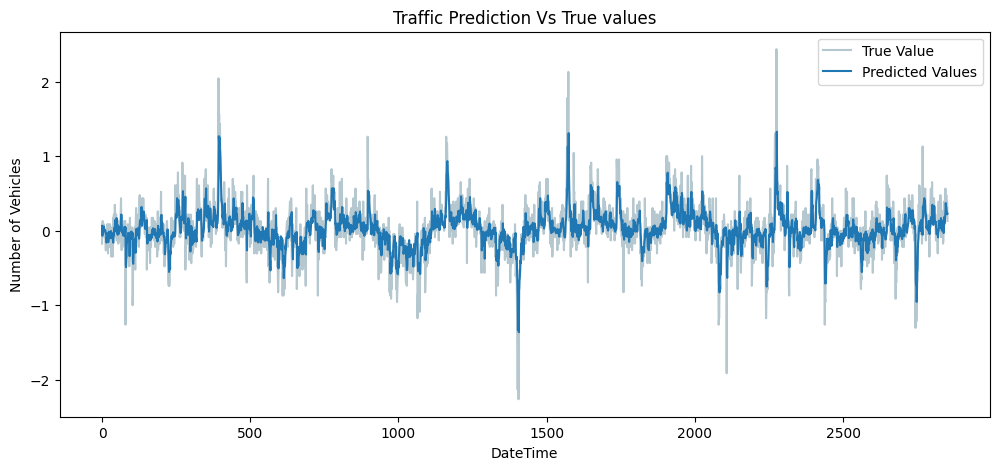

In [16]:
colors = ["#6D91A1","#74B3CE1","#536D7A","#3E535B"]
RMSE_MLP = RMSE_Value(y_test, Pred_MLP)
MAE_MLP = MAE_Value(y_test, Pred_MLP)
PredictionsPlot(y_test, Pred_MLP, 0)

In [17]:
def inverse_difference(last_ob, value):
    inversed = value + last_ob
    return inversed

def Sub_Plots(df_1, df_2,title,m):
    fig, axes = plt.subplots(1, 2, figsize=(18,4), sharey=True)
    fig.suptitle(title)
    
    pl_1=sns.lineplot(ax=axes[0],data=df_1,color=colors[m])
    axes[0].set(ylabel ="Prediction")
    
    pl_2=sns.lineplot(ax=axes[1],data=df_2["Vehicles"],color="#3E535B")
    axes[1].set(ylabel ="Original")

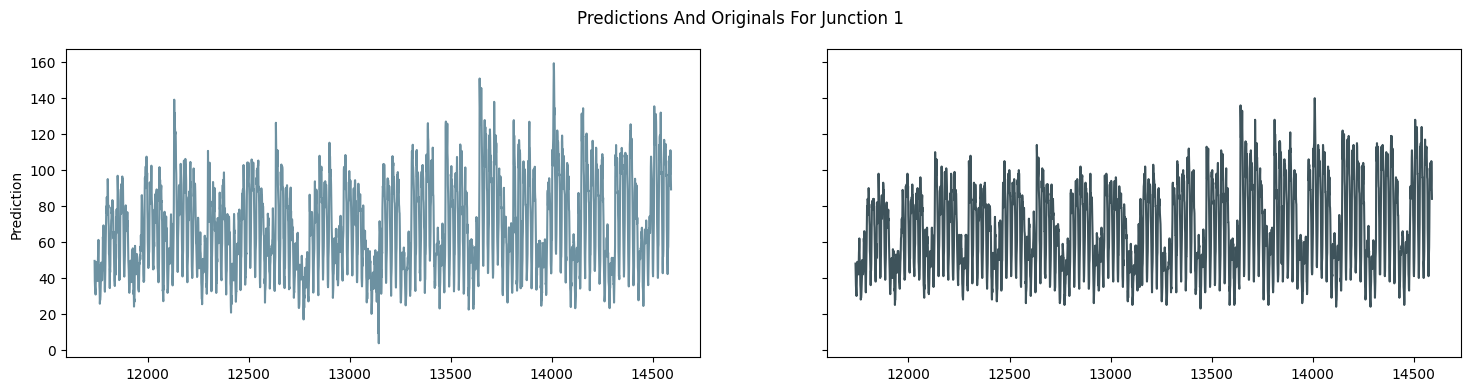

In [18]:
recover = df_N.Norm[-2854:-1].to_frame()
recover["Pred"]= globals()[f"Pred_MLP"]
Transform_reverssed = inverse_difference(recover.Norm, recover.Pred).to_frame()
Transform_reverssed.columns = ["Pred_Normed"]
Final_Pred = (Transform_reverssed.values* std) + av
Transform_reverssed["Pred_Final"] = Final_Pred
Sub_Plots(Transform_reverssed["Pred_Final"], data[-2854:-1],"Predictions And Originals For Junction 1", 0)

In [19]:
def GRU_model(X_Train, y_Train, X_Test, y_Test):
    early_stopping = callbacks.EarlyStopping(min_delta=0.001,patience=10, restore_best_weights=True) 
    #callback delta 0.01 may interrupt the learning.
    
    #The GRU model 
    model = Sequential()
    model.add(GRU(units=100, return_sequences=True, input_shape=(X_Train.shape[1],1), activation='tanh'))
    model.add(Dropout(0.2))
    model.add(GRU(units=20, input_shape=(X_Train.shape[1],1), activation='tanh'))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    #Compiling the model
    model.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9),loss='mean_squared_error')
    model.fit(X_Train,y_Train, validation_data=(X_Test, y_Test), epochs=50, batch_size=120,callbacks=[early_stopping])
    pred_GRU= model.predict(X_Test)
    return pred_GRU

In [20]:
def LSTM_model(X_Train, y_Train, X_Test, y_Test):
    early_stopping = callbacks.EarlyStopping(min_delta=0.001,patience=10, restore_best_weights=True) 
    
    #The LSTM model 
    model = Sequential()
    model.add(LSTM(units=100, return_sequences=True, input_shape=(X_Train.shape[1],1), activation='tanh'))
    model.add(Dropout(0.2))
    model.add(LSTM(units=20, input_shape=(X_Train.shape[1],1), activation='tanh'))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    
    #Compiling the model
    model.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9),loss='mean_squared_error')
    model.fit(X_Train,y_Train, validation_data=(X_Test, y_Test), epochs=50, batch_size=120,callbacks=[early_stopping])
    pred_LSTM = model.predict(X_Test)
    return pred_LSTM

In [21]:
Pred_GRU = GRU_model(X_train,y_train,X_test,y_test)

Epoch 1/50
96/96 [==============================] - 7s 38ms/step - loss: 0.0592 - val_loss: 0.0639
Epoch 2/50
96/96 [==============================] - 3s 31ms/step - loss: 0.0490 - val_loss: 0.0614
Epoch 3/50
96/96 [==============================] - 3s 31ms/step - loss: 0.0477 - val_loss: 0.0605
Epoch 4/50
96/96 [==============================] - 3s 30ms/step - loss: 0.0473 - val_loss: 0.0588
Epoch 5/50
96/96 [==============================] - 3s 31ms/step - loss: 0.0463 - val_loss: 0.0585
Epoch 6/50
96/96 [==============================] - 3s 31ms/step - loss: 0.0462 - val_loss: 0.0575
Epoch 7/50
96/96 [==============================] - 3s 31ms/step - loss: 0.0458 - val_loss: 0.0572
Epoch 8/50
96/96 [==============================] - 3s 31ms/step - loss: 0.0456 - val_loss: 0.0575
Epoch 9/50
96/96 [==============================] - 3s 31ms/step - loss: 0.0457 - val_loss: 0.0564
Epoch 10/50
96/96 [==============================] - 3s 31ms/step - loss: 0.0448 - val_loss: 0.0568
Epoch 11/

The root mean squared error is 0.23751491210882214.
The MAE is 0.1717113773412267.


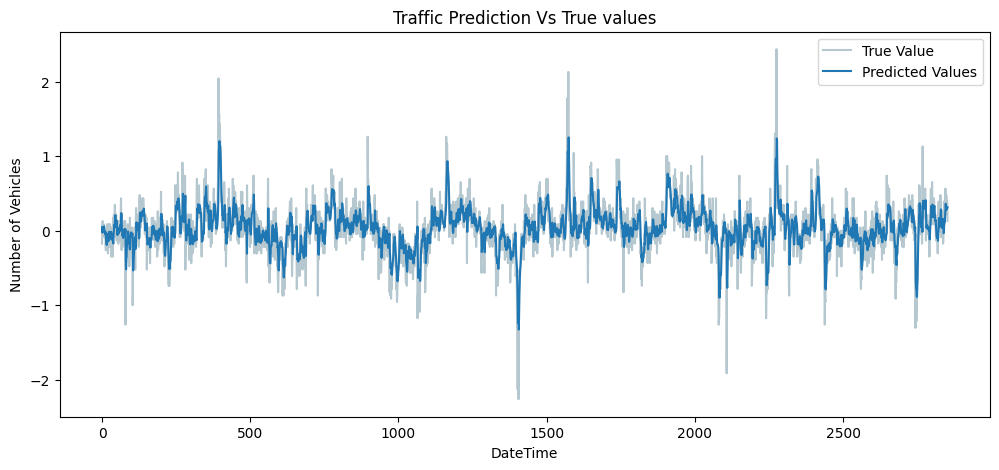

In [22]:
RMSE_GRU = RMSE_Value(y_test, Pred_GRU)
MAE_GRU = MAE_Value(y_test, Pred_GRU)
PredictionsPlot(y_test, Pred_GRU, 0)

In [23]:
Pred_LSTM = LSTM_model(X_train,y_train,X_test, y_test)

Epoch 1/50
96/96 [==============================] - 8s 47ms/step - loss: 0.0696 - val_loss: 0.0830
Epoch 2/50
96/96 [==============================] - 4s 45ms/step - loss: 0.0606 - val_loss: 0.0785
Epoch 3/50
96/96 [==============================] - 4s 45ms/step - loss: 0.0581 - val_loss: 0.0760
Epoch 4/50
96/96 [==============================] - 5s 50ms/step - loss: 0.0563 - val_loss: 0.0736
Epoch 5/50
96/96 [==============================] - 4s 46ms/step - loss: 0.0551 - val_loss: 0.0727
Epoch 6/50
96/96 [==============================] - 4s 42ms/step - loss: 0.0543 - val_loss: 0.0702
Epoch 7/50
96/96 [==============================] - 4s 44ms/step - loss: 0.0536 - val_loss: 0.0690
Epoch 8/50
96/96 [==============================] - 4s 43ms/step - loss: 0.0526 - val_loss: 0.0676
Epoch 9/50
96/96 [==============================] - 4s 43ms/step - loss: 0.0520 - val_loss: 0.0664
Epoch 10/50
96/96 [==============================] - 4s 43ms/step - loss: 0.0517 - val_loss: 0.0655
Epoch 11/

The root mean squared error is 0.23847301593267392.
The MAE is 0.17239614037706041.


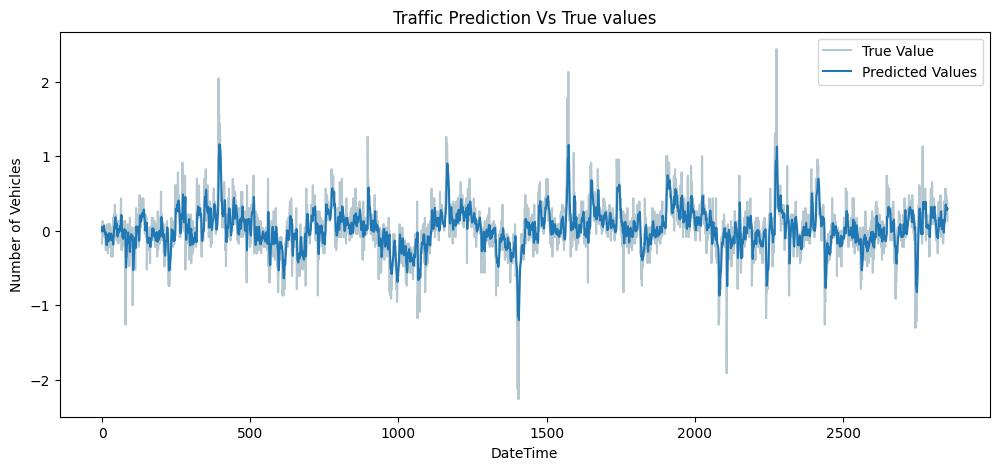

In [24]:
RMSE_LSTM = RMSE_Value(y_test, Pred_LSTM)
MAE_LSTM = MAE_Value(y_test, Pred_LSTM)
PredictionsPlot(y_test, Pred_LSTM, 0)